# 01 — Coastal Virginia elevation (retargeted)

High-ground search for the relocation: a house in southeastern Virginia within
Larissa's **30-mile-of-the-beach** rule, with the surf/water access handled
separately by a marina slip in the northern OBX. Because the house no longer
carries the water-access job, it's free to sit on inland high ground — which is
exactly where the safe ground is here.

Retargeted from the 17-county NC pipeline. What carried over unchanged: the
20 ft NAVD88 threshold, the bare-earth DTM requirement, the buildable-pad test,
the cell-size assertion, 10 m 3DEP resolution, UTM 18N. What changed: the area
(three VA localities), and one hard gate that didn't exist in NC — the beach
rule.

## The landscape, in one paragraph

This is not Carteret. There are no waterfront bluffs. The relief here is the
**Suffolk Scarp**, a relict shoreline ~20 mi inland: ground east of it is the
low terrace that stood underwater at a +20-25 ft highstand, ground on and west
of it is the buildable high ground. Larissa's rule pulls the search *east*
(toward the beach, low and wet); the 20 ft rule pulls it *west* (inland, high
and dry). The winners are the thin band where the scarp's eastern reach still
falls inside 30 miles. **Expect far fewer hits than NC** — that's the terrain
being honest, not the pipeline failing.

## One caveat this coast adds: subsidence

Hampton Roads has among the highest *relative* sea-level-rise rates in the
country because the land is actively sinking. The 10 m DEM measures today's
ground; a finalist's true long-horizon margin is a touch less than measured.
Reason enough to keep the 20 ft threshold and the pond-spoil pad-raise, and to
end on 1 m lidar before any offer.

## 1 · Config

In [11]:
from pathlib import Path
import numpy as np, pandas as pd
import warnings; warnings.filterwarnings("ignore")

import py3dep, pygris
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin
from shapely.geometry import mapping
from scipy import ndimage

import va_aoi as A          # shared geography (localities, beach rule, exclusions)
import nc_palette as pal    # unchanged banded palette

DEM_DIR = Path("data/dem");     DEM_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR = Path("output");       OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "maps").mkdir(exist_ok=True)

M_TO_FT = 3.280839895
DEM_RES = 10                    # 3DEP 1/3 arc-second, ~10 m

print("localities:", ", ".join(A.LOCALITIES))
print(f"beach rule: {A.BEACH_RULE_MI:g} mi  |  coarse buffer: {A.BEACH_BUFFER_MI:g} mi")
print(f"threshold:  {A.THRESHOLD_FT:g} ft NAVD88")

localities: Virginia_Beach, Chesapeake, Suffolk
beach rule: 30 mi  |  coarse buffer: 31 mi
threshold:  20 ft NAVD88


## 2 · Build the clipped AOI

In [12]:
# --- Build the clipped AOI --------------------------------------------------
# Locality polygons intersected with the beach buffer. We fetch DEM only for the
# in-range slice -- no point pulling western Suffolk we'll never use.

cty = pygris.counties(state=A.STATE_FIPS, cb=True, year=2023, cache=True)
cty["GEOID"] = cty["GEOID"].astype(str)
targets = cty[cty.GEOID.isin(A.LOCALITIES.values())].to_crs(A.WORKING_EPSG)
print(f"{len(targets)} localities pulled:", ", ".join(sorted(targets.NAME)))

buffer_utm = A.beach_buffer_geom()          # UTM 18N meters
targets["clipped"] = targets.geometry.intersection(buffer_utm)
targets = targets[~targets.clipped.is_empty].copy()

for _, r in targets.iterrows():
    full = r.geometry.area / 1609.344**2
    clip = r.clipped.area / 1609.344**2
    print(f"  {r.NAME:<16} {clip:6.1f} / {full:6.1f} sq mi in range "
          f"({100*clip/full:4.0f}%)")

3 localities pulled: Chesapeake, Suffolk, Virginia Beach
  Suffolk            79.1 /  416.3 sq mi in range (  19%)
  Virginia Beach    306.5 /  306.5 sq mi in range ( 100%)
  Chesapeake        345.7 /  350.7 sq mi in range (  99%)


## 3 · Fetch 3DEP per locality

In [13]:
import time
import numpy as np
from shapely.geometry import box
from rioxarray.merge import merge_arrays

def fetch_dem_tiled(name, geom_utm, tile_deg=0.07, res=DEM_RES, tries=4):
    """Fetch one locality as small tiles and mosaic — reliable when whole-locality fails."""
    fp = DEM_DIR / f"{name}.tif"
    if fp.exists():
        print(f"  cached  {name}")
        return fp
    geom_wgs = gpd.GeoSeries([geom_utm], crs=A.WORKING_EPSG).to_crs(4326).iloc[0]
    minx, miny, maxx, maxy = geom_wgs.bounds
    nx = int(np.ceil((maxx - minx) / tile_deg))
    ny = int(np.ceil((maxy - miny) / tile_deg))
    pad = 0.0015
    print(f"  {name}: {nx}x{ny} grid")
    tiles = []
    for i in range(nx):
        for j in range(ny):
            cell = box(minx + i*tile_deg - pad, miny + j*tile_deg - pad,
                       minx + (i+1)*tile_deg + pad, miny + (j+1)*tile_deg + pad)
            piece = cell.intersection(geom_wgs)
            if piece.is_empty:
                continue
            for attempt in range(1, tries + 1):
                try:
                    tiles.append(py3dep.get_map("DEM", piece, resolution=res,
                                                geo_crs=4326, crs=4326))
                    break
                except Exception:
                    if attempt < tries:
                        time.sleep(3 * attempt)
            time.sleep(0.3)
    if not tiles:
        print(f"  [skip] {name}")
        return None
    mosaic = merge_arrays(tiles) if len(tiles) > 1 else tiles[0]
    mosaic = mosaic.rio.reproject(A.WORKING_EPSG)
    mosaic.rio.to_raster(fp)
    print(f"  [ok] {name}: {len(tiles)} tiles -> {mosaic.shape}")
    return fp

# Loop ALL three localities. Cached ones skip instantly; anything missing
# gets tiled automatically.
tifs = {}
for _, r in targets.iterrows():
    key = r.NAME.replace(" ", "_")
    fp = fetch_dem_tiled(key, r.geometry)
    if fp is not None:
        tifs[key] = fp
print(f"\n{len(tifs)} DEMs ready")

  cached  Suffolk
  cached  Virginia_Beach
  cached  Chesapeake

3 DEMs ready


## 4 · Find high-ground regions

In [14]:
# ============================================================================
# 4a · Compute high-ground regions + CACHE cleaned arrays   [SLOW - run once]
# ============================================================================
# Reads each DEM, clips to the county boundary, cleans it, finds regions, and
# SAVES the cleaned elevation array to cache/arrays/. Re-running the *maps*
# (cell 4b) then reloads these in ~2 s instead of recomputing for 20 min.
# Only re-run THIS cell if the underlying DEM data changes.

from rasterio.features import geometry_mask

CACHE_ARR = Path("cache/arrays"); CACHE_ARR.mkdir(parents=True, exist_ok=True)
MAX_REAL_FT = 50.0     # coastal ceiling; RAISE if AOI ever goes inland (>50ft real)

geom_by_name = {r.NAME.replace(" ", "_"): r.geometry for _, r in targets.iterrows()}


def largest_pad_acres(mask, cell_m):
    if mask.sum() == 0:
        return 0.0
    edt = ndimage.distance_transform_edt(mask) * cell_m
    return np.pi * edt.max() ** 2 / 4046.8564224


def analyze(name, path, geom_utm):
    with rasterio.open(path) as src:
        z = src.read(1).astype("float32")
        assert src.crs.to_epsg() == A.WORKING_EPSG, f"{name}: wrong CRS"
        cw = abs(src.transform.a)
        assert 5.0 <= cw <= 15.0, f"{name}: cell {cw:.1f} m -- expected ~{DEM_RES} m"
        nod = src.nodata
        tr = src.transform
        b = src.bounds
        extent = (b.left, b.right, b.bottom, b.top)
        outside = geometry_mask([geom_utm], out_shape=z.shape, transform=tr, invert=False)

    if nod is not None:
        z[z == nod] = np.nan
    z[outside] = np.nan                        # clip to county -> kills out-of-line black
    z[z < -100] = np.nan
    ft = z * M_TO_FT
    ft[ft < -2] = np.nan
    ft[ft > MAX_REAL_FT] = np.nan

    high = np.nan_to_num(ft, nan=-999) >= A.THRESHOLD_FT
    lbl, n = ndimage.label(high)
    rows = []
    for i in range(1, n + 1):
        m = lbl == i
        acres = m.sum() * cw * cw / 4046.8564224
        if acres < 1.0:
            continue
        ys, xs = np.where(m)
        cx, cy = tr * (xs.mean(), ys.mean())
        pad = largest_pad_acres(m, cw)
        rows.append(dict(locality=name, region_id=i, acres=acres,
                         mean_ft=float(np.nanmean(ft[m])), max_ft=float(np.nanmax(ft[m])),
                         pad_acres=pad, pad_fits=pad >= A.MIN_PAD_ACRES, x=cx, y=cy))
    return ft, extent, cw, pd.DataFrame(rows)


all_regions, stats = [], []
for name, path in tifs.items():
    ft, extent, cw, df = analyze(name, path, geom_by_name[name])
    # cache the cleaned array so map-tweaking never recomputes
    np.savez_compressed(CACHE_ARR / f"{name}.npz",
                        ft=ft, extent=np.array(extent), cw=cw)
    land = ~np.isnan(ft)
    stats.append(dict(locality=name,
                      pct_over_20=100*float((ft[land] >= A.THRESHOLD_FT).mean()),
                      mean_ft=float(np.nanmean(ft)), max_ft=float(np.nanmax(ft)),
                      n_regions=len(df),
                      n_buildable=int(df.pad_fits.sum()) if len(df) else 0))
    all_regions.append(df)
    print(f"  {name:<16} {len(df):4d} regions, "
          f"{int(df.pad_fits.sum()) if len(df) else 0:3d} buildable, "
          f"{stats[-1]['pct_over_20']:5.1f}% >=20ft  [cached]")

regions = pd.concat(all_regions, ignore_index=True) if all_regions else pd.DataFrame()
summary = pd.DataFrame(stats).sort_values("pct_over_20", ascending=False)
print()
print(summary.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

  Suffolk           373 regions,  61 buildable,  69.8% >=20ft  [cached]
  Virginia_Beach    328 regions,  40 buildable,   4.3% >=20ft  [cached]
  Chesapeake        570 regions,  58 buildable,   8.2% >=20ft  [cached]

      locality  pct_over_20  mean_ft  max_ft  n_regions  n_buildable
       Suffolk        69.78    24.36   50.00        373           61
    Chesapeake         8.21    13.11   50.00        570           58
Virginia_Beach         4.26     7.17   50.00        328           40


In [17]:
# ============================================================================
# 4b · Render maps from cache            [FAST - re-run to tweak the look]
# ============================================================================
# Loads the cached arrays (no recompute) and draws each county with a hard
# black border. Tweak colors/borders/labels here and re-run in ~2 seconds.

CACHE_ARR = Path("cache/arrays")
geom_by_name = {r.NAME.replace(" ", "_"): r.geometry for _, r in targets.iterrows()}

BORDER_WIDTH = 1.6      # <-- tweak me
BORDER_COLOR = "black"  # <-- tweak me

for f in sorted(CACHE_ARR.glob("*.npz")):
    name = f.stem
    d = np.load(f)
    ft, extent = d["ft"], tuple(d["extent"])

    fig_ax = pal.plot_county(ft, name.replace("_", " "),
                             extent=extent, threshold_contour=False)

    # hard county border, drawn in the same map coords as the raster
    gpd.GeoSeries([geom_by_name[name]], crs=A.WORKING_EPSG).boundary.plot(
        ax=fig_ax, edgecolor=BORDER_COLOR, linewidth=BORDER_WIDTH, zorder=5)
    fig_ax.set_xlim(extent[0], extent[1])
    fig_ax.set_ylim(extent[2], extent[3])

    fig_ax.figure.savefig(OUT_DIR / "maps" / f"{name}.png",
                          dpi=130, bbox_inches="tight", facecolor="white")
    fig_ax.figure.clf()
    print(f"  drew {name}")

print("maps -> output/maps/")

  drew Chesapeake
  drew Suffolk
  drew Virginia_Beach
maps -> output/maps/


<Figure size 1100x900 with 0 Axes>

<Figure size 1100x900 with 0 Axes>

<Figure size 1100x900 with 0 Axes>

## 5 · Beach distance + save

In [16]:
# --- Attach beach distance, save --------------------------------------------
# Convert region centroids to lon/lat, add the coarse straight-line beach
# distance as a COLUMN. The gate happens in triage (02), not here.

if len(regions):
    ll = gpd.GeoSeries(gpd.points_from_xy(regions.x, regions.y),
                       crs=A.WORKING_EPSG).to_crs(4326)
    regions["lon"] = ll.x.values
    regions["lat"] = ll.y.values
    regions["beach_mi"] = A.dist_to_beach_mi(regions.lon.values, regions.lat.values)

regions.to_csv(OUT_DIR / "regions_20ft.csv", index=False)
summary.to_csv(OUT_DIR / "county_summary.csv", index=False)

print(summary.to_string(index=False, float_format=lambda v: f"{v:7.2f}"))
print(f"\n[ok] {len(regions)} regions -> output/regions_20ft.csv")
print(f"[ok] {len(tifs)} maps -> output/maps/")
if len(regions):
    within = (regions.beach_mi <= A.BEACH_RULE_MI).sum()
    print(f"\n{within}/{len(regions)} regions inside the {A.BEACH_RULE_MI:g}-mi "
          f"straight-line beach rule (drive-time refines these in triage)")

      locality  pct_over_20  mean_ft  max_ft  n_regions  n_buildable
       Suffolk        69.78    24.36   50.00        373           61
    Chesapeake         8.21    13.11   50.00        570           58
Virginia_Beach         4.26     7.17   50.00        328           40

[ok] 1271 regions -> output/regions_20ft.csv
[ok] 3 maps -> output/maps/

1032/1271 regions inside the 30-mi straight-line beach rule (drive-time refines these in triage)


## 6 North Carolina Marinas

[ok] 159 high-ground pockets · 3 evening beaches · 7 launches -> output/access_overview.png


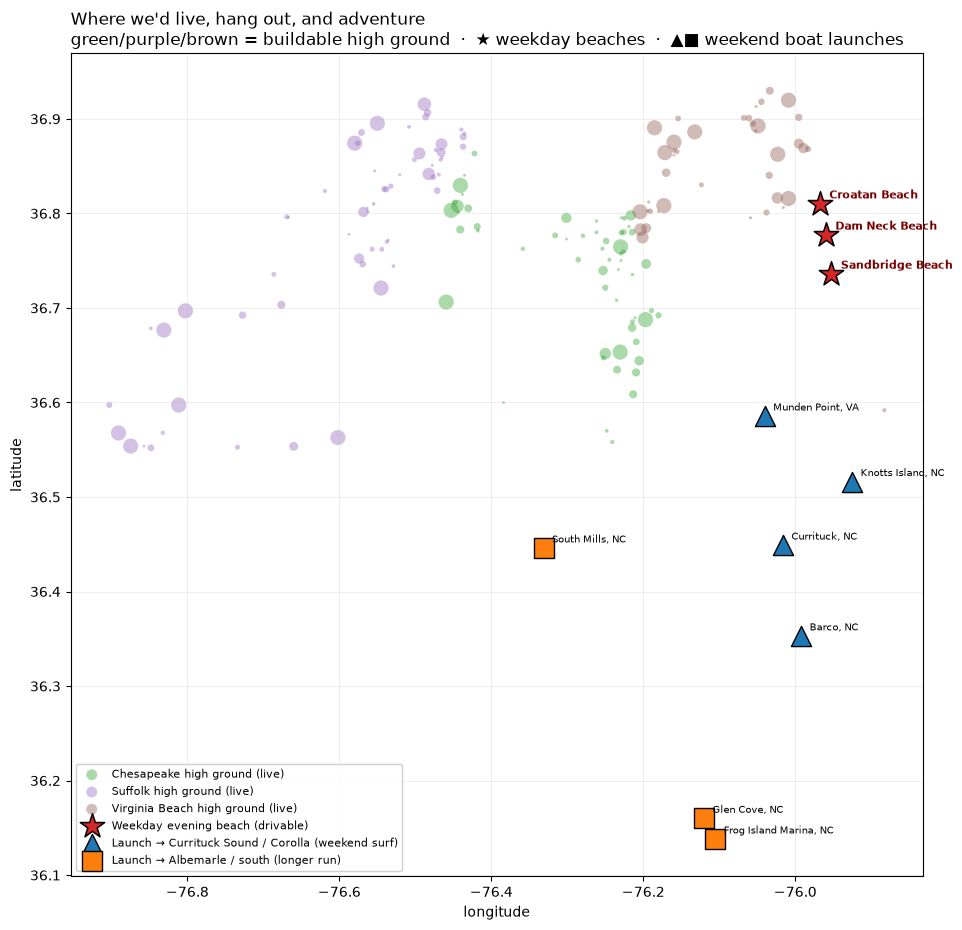

In [19]:
# ============================================================================
# 6 · Access overview: where we live, hang out, and adventure   [self-contained]
# ============================================================================
# Reads output/regions_20ft.csv. Three layers on one picture:
#   - buildable high ground (where we'd LIVE), colored by locality
#   - weekday evening beaches (where we HANG OUT), drivable ocean
#   - boat launches (how we get to the WEEKEND surf across the sound)
# Pure reference layer -- changes nothing upstream. Nudge coordinates freely.

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = Path("output")

# --- Weekday evening spots: drivable ocean beach, where we actually hang out -
EVENING = {
    "Sandbridge Beach":  (36.7357, -75.9527),
    "Croatan Beach":     (36.8100, -75.9680),   # by Rudee Inlet
    "Dam Neck Beach":    (36.7770, -75.9600),
}

# --- Boat launches -> weekend adventures across the sound -------------------
# 'currituck' = Currituck Sound -> Corolla / Currituck Banks (target surf)
# 'albemarle' = Albemarle system -> south, longer run, dodges the OBX crowds
# (*) = coordinate approximate, verify/nudge in December
LAUNCHES = {
    "Munden Point, VA":       (36.5856, -76.0400, "currituck"),   # verified
    "Knotts Island, NC":      (36.5163, -75.9250, "currituck"),   # *
    "Currituck, NC":          (36.4490, -76.0160, "currituck"),   # *
    "Barco, NC":              (36.3530, -75.9920, "currituck"),   # *
    "South Mills, NC":        (36.4460, -76.3310, "albemarle"),   # *
    "Frog Island Marina, NC": (36.1381, -76.1051, "albemarle"),   # verified
    "Glen Cove, NC":          (36.1600, -76.1200, "albemarle"),   # *
}

FAMILY = {
    "currituck": dict(color="#1f77b4", marker="^", label="Launch \u2192 Currituck Sound / Corolla (weekend surf)"),
    "albemarle": dict(color="#ff7f0e", marker="s", label="Launch \u2192 Albemarle / south (longer run)"),
}
EVENING_STYLE = dict(color="#d62728", marker="*", s=340,
                     label="Weekday evening beach (drivable)")

LOC_COLOR = {"Chesapeake": "#2ca02c", "Virginia_Beach": "#8c564b", "Suffolk": "#9467bd"}

# --- Load buildable high ground ---------------------------------------------
r = pd.read_csv(OUT_DIR / "regions_20ft.csv")
build = r[r.pad_fits].copy() if "pad_fits" in r.columns else r.copy()

fig, ax = plt.subplots(figsize=(11, 12))

# where we'd LIVE: high-ground pockets, sized by acreage, colored by locality
for loc, sub in build.groupby("locality"):
    ax.scatter(sub.lon, sub.lat, s=np.clip(sub.acres, 4, 120),
               c=LOC_COLOR.get(loc, "#555555"), alpha=0.40,
               edgecolors="none", label=f"{loc.replace('_',' ')} high ground (live)")

# where we HANG OUT: weekday evening beaches
first = True
for name, (lat, lon) in EVENING.items():
    ax.scatter(lon, lat, edgecolors="black", linewidths=1.1, zorder=7,
               label=(EVENING_STYLE["label"] if first else None),
               color=EVENING_STYLE["color"], marker=EVENING_STYLE["marker"],
               s=EVENING_STYLE["s"])
    ax.annotate(name, (lon, lat), xytext=(7, 4), textcoords="offset points",
                fontsize=8, fontweight="bold", color="#7a0000", zorder=8)
    first = False

# how we get to the WEEKEND adventures: boat launches
seen = set()
for name, (lat, lon, fam) in LAUNCHES.items():
    f = FAMILY[fam]
    lbl = f["label"] if fam not in seen else None
    seen.add(fam)
    ax.scatter(lon, lat, c=f["color"], marker=f["marker"], s=210,
               edgecolors="black", linewidths=1.0, zorder=6, label=lbl)
    ax.annotate(name, (lon, lat), xytext=(6, 4), textcoords="offset points",
                fontsize=7.5, zorder=7)

ax.set_title("Where we'd live, hang out, and adventure\n"
             "green/purple/brown = buildable high ground  \u00b7  "
             "\u2605 weekday beaches  \u00b7  \u25b2\u25a0 weekend boat launches",
             fontsize=12, loc="left")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.legend(loc="lower left", fontsize=8, framealpha=0.92)
ax.grid(alpha=0.2)
ax.set_aspect(1/np.cos(np.radians(36.5)))

fig.savefig(OUT_DIR / "access_overview.png", dpi=130, bbox_inches="tight", facecolor="white")
print(f"[ok] {len(build)} high-ground pockets \u00b7 {len(EVENING)} evening beaches \u00b7 "
      f"{len(LAUNCHES)} launches -> output/access_overview.png")
plt.show()